In [1]:
import yaml
import os.path as op
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def read_clustering_score_from_yaml(analysis_output_dir):
    """Reads the clustering score YAML and returns the float value."""
    file_path = op.join(analysis_output_dir, 'clustering_score.yaml')
    print(file_path)
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
        
    return data['clustering_score']

# Usage:
# score = read_clustering_score_from_yaml('/path/to/output')
# print(f"Loaded score: {score}")

In [2]:
def get_clustering_scores_for_category(basepath, list_of_score_files, category = 'x-dataset'):
    scores = []
    filenames = []
    for n in list_of_score_files:
        try:
            score = read_clustering_score_from_yaml(op.join(basepath,n ))
            print(score)
            scores.append(score)
            filenames.append(n)
        except:
            pass
    score_df = pd.DataFrame({'name':filenames, 'score':scores})
    score_df['category'] = category
    return score_df
    

In [3]:

basepath = '/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/'
list_of_score_files = ['bd-rhap-rep1-X', 'bd-rhap-rep2-X', '10x-rep1-kallisto-cellbender-X', 'blood-10x-rep2-kallisto-cellbender-X']
score_df_xd = get_clustering_scores_for_category(basepath, list_of_score_files, 'cross-  \ndataset')

/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep1-X/clustering_score.yaml
0.974462242562929
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-X/clustering_score.yaml
0.9834364398323688
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-X/clustering_score.yaml
0.9584756898817346
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/blood-10x-rep2-kallisto-cellbender-X/clustering_score.yaml
0.9420910993720721


In [4]:
basepath = '/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/'
list_of_score_files = [f'10x-rep1-kallisto-cellbender-X-{i}' for i in range(10)]
score_df_wd = get_clustering_scores_for_category(basepath, list_of_score_files, 'within- \ndataset-10x')

/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-X-0/clustering_score.yaml
0.9529566360052563
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-X-1/clustering_score.yaml
0.9562417871222076
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-X-2/clustering_score.yaml
0.957161629434954
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-X-3/clustering_score.yaml
0.9528252299605782
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-X-4/clustering_score.yaml
0.9509855453350854
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-X-5/clustering_score.yaml
0.9164257555847569
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analys

In [5]:
basepath = '/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/'
list_of_score_files = [f'bd-rhap-rep2-X-{i}' for i in range(10)]
score_df_bd = get_clustering_scores_for_category(basepath, list_of_score_files, 'within- \ndataset-bd')

/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-X-0/clustering_score.yaml
0.9787134969733253
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-X-1/clustering_score.yaml
0.9848333665934943
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-X-2/clustering_score.yaml
0.9828377569347435
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-X-3/clustering_score.yaml
0.9800439034124925
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-X-4/clustering_score.yaml
0.9851659682032861
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-X-5/clustering_score.yaml
0.981440830173618
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-X-6/clustering_score.yaml
0.9127918579125923
/data_nfs/og86asub/netmap/netmap-ev

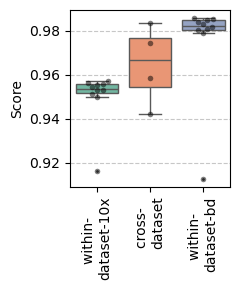

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

score_df = pd.concat([score_df_wd, score_df_xd, score_df_bd])
# 1. Set Figure Size
plt.figure(figsize=(2.5, 3)) # 3x2 was likely too small for labels to show

# 2. Plot Boxplot
# Note: Since x and hue are the same, we set dodge=False to keep them centered on the tick
g = sns.boxplot(
    data=score_df, 
    x='category', 
    y='score', 
    hue='category', 
    palette='Set2', 
    legend=False,
    dodge=False,
    fliersize = 1
)

# 3. Overlay Swarmplot 
# dodge=False ensures the dots stay centered on the box
sns.swarmplot(
    data=score_df, 
    x='category', 
    y='score', 
    color='black', 
    alpha=0.5,
    size=4,
)

# 4. Formatting
plt.xticks(rotation=90, ha='center')
plt.xlabel('') # Removing redundant x-label
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/clustering_scores_blood.pdf')
plt.show()


In [7]:
score_df.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/clustering_scores_data_file.tsv', sep = '\t')